In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración estética para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Ruta del archivo
file_name = "benchmark_granular_workflow.csv"

if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print(f"¡Dataset cargado con éxito desde '{file_name}'!")
    print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas.\n")
    print(df.head())
else:
    print(f"Error: No se encontró el archivo '{file_name}' en el directorio actual.")
    print(f"Directorio de trabajo actual: {os.getcwd()}")

¡Dataset cargado con éxito desde 'benchmark_granular_workflow.csv'!
Dimensiones: 180 filas, 10 columnas.

   sample  n_nets   perfil      t_p1      t_p2      t_p3   total_t  \
0       1       5      seq  0.319333  0.000351  0.000123  0.319807   
1       1       5      par  0.133742  0.015022  0.014424  0.163188   
2       1       5  weights  0.124096  0.015938  0.000283  0.140318   
3       1       6      seq  0.360347  0.000206  0.000112  0.360665   
4       1       6      par  0.130224  0.016716  0.013793  0.160732   

   n_attractors  n_pairs  n_fields  
0            13        6         0  
1            13        6         0  
2            13        6         0  
3            18        4         0  
4            18        4         0  


In [3]:
# Agrupamos por muestra y número de redes calculando el promedio global de tiempos
# y el valor real de descriptores topológicos encontrados
grouped_df = df.groupby(['sample', 'n_nets']).agg({
    't_p1': 'mean',
    't_p2': 'mean',
    't_p3': 'mean',
    'total_t': 'mean',
    'n_attractors': 'first', # Es igual para los 3 perfiles del experimento
    'n_pairs': 'first',      # Es igual para los 3 perfiles del experimento
    'n_fields': 'first'      # Es igual para los 3 perfiles del experimento
}).reset_index()

print("--- Datos agrupados por Sample y Número de Redes (Muestra de los primeros 10) ---")
grouped_df.head(10)

--- Datos agrupados por Sample y Número de Redes (Muestra de los primeros 10) ---


,sample,n_nets,t_p1,t_p2,t_p3,total_t,n_attractors,n_pairs,n_fields
0,1,5,0.192390,0.010437,0.004943,0.207771,13,6,0
1,1,6,0.205631,0.011187,0.004733,0.221551,18,4,0
2,1,7,0.260616,0.010751,0.004934,0.276301,19,6,0
3,1,8,0.310651,0.011322,0.004939,0.326913,22,10,0
4,1,9,0.360485,0.011679,0.004678,0.376842,25,12,0
5,1,10,0.348955,0.012977,0.005201,0.367134,29,10,0
6,2,5,0.206026,0.013939,0.006458,0.226424,13,0,0
7,2,6,0.261540,0.017899,0.008228,0.287667,16,0,0
8,2,7,0.271134,0.017552,0.005319,0.294005,19,6,0
9,2,8,0.288947,0.015455,0.007602,0.312004,22,0,0


In [4]:
# Pivotamos los datos para evaluar el comportamiento promedio de cada perfil al escalar el sistema
pivot_profiles = df.groupby(['n_nets', 'perfil'])['total_t'].mean().unstack()

print("--- Tiempo Total Promedio (segundos) por Número de Redes y Perfil ---")
pivot_profiles

--- Tiempo Total Promedio (segundos) por Número de Redes y Perfil ---


perfil,par,seq,weights
n_nets,,,
5,0.176322,0.314905,0.156436
6,0.185443,0.385614,0.167289
7,0.193957,0.468712,0.184754
8,0.229962,0.531200,0.221752
9,0.271984,0.615625,0.257792
10,0.274610,0.701426,0.266813


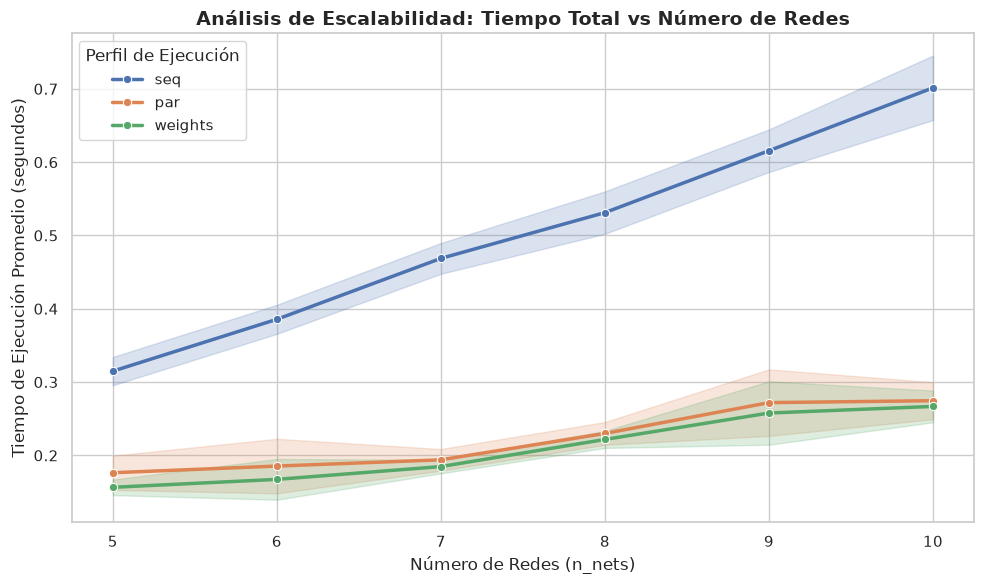

In [5]:
plt.figure(figsize=(10, 6))

# Dibujar las tendencias promedio usando Seaborn
sns.lineplot(data=df, x='n_nets', y='total_t', hue='perfil', marker='o', linewidth=2.5, errorbar='sd')

plt.title('Análisis de Escalabilidad: Tiempo Total vs Número de Redes', fontsize=14, fontweight='bold')
plt.xlabel('Número de Redes (n_nets)', fontsize=12)
plt.ylabel('Tiempo de Ejecución Promedio (segundos)', fontsize=12)
plt.legend(title='Perfil de Ejecución')
plt.tight_layout()
plt.show()

--- Distribución Porcentual del Tiempo por Fase Interna ---
            t_p1    t_p2    t_p3
perfil                          
par      84.06 %   8.4 %  7.54 %
seq      99.92 %  0.06 %  0.02 %
weights  90.55 %  9.29 %  0.15 %


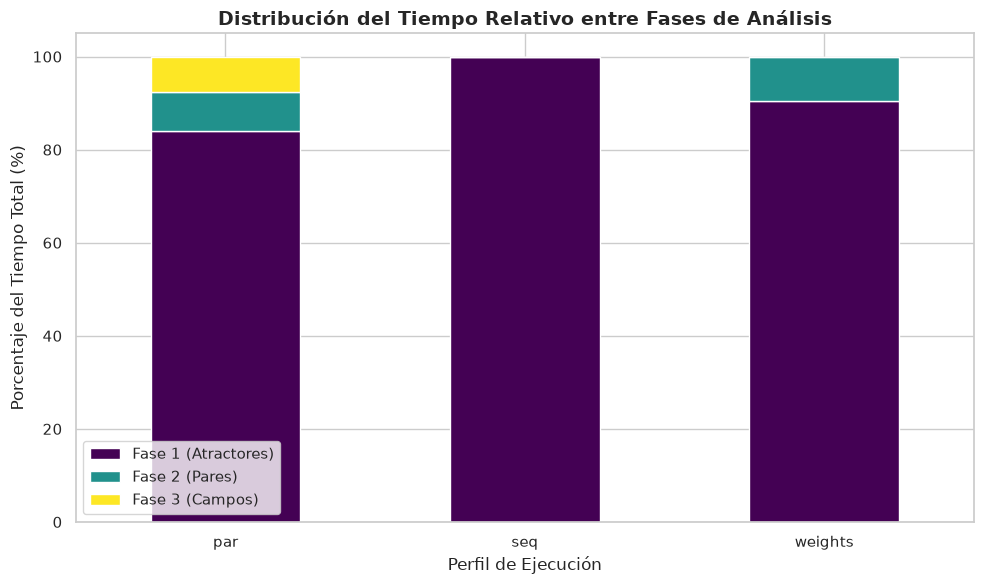

In [6]:
# Obtener promedios por perfil
fases_summary = df.groupby('perfil')[['t_p1', 't_p2', 't_p3']].mean()

# Normalizar a porcentajes para análisis de componentes relativos
fases_percentage = fases_summary.div(fases_summary.sum(axis=1), axis=0) * 100

print("--- Distribución Porcentual del Tiempo por Fase Interna ---")
print(fases_percentage.round(2).astype(str) + ' %')

# Gráfico de barras apiladas
fases_percentage.plot(kind='bar', stacked=True, cmap='viridis', figsize=(10, 6))
plt.title('Distribución del Tiempo Relativo entre Fases de Análisis', fontsize=14, fontweight='bold')
plt.xlabel('Perfil de Ejecución', fontsize=12)
plt.ylabel('Porcentaje del Tiempo Total (%)', fontsize=12)
plt.legend(['Fase 1 (Atractores)', 'Fase 2 (Pares)', 'Fase 3 (Campos)'], loc='lower left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()